In [1]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path
import pickle
from benchmark.examples.gaussian.direct.simulator import DirectSimulator   
from benchmark.examples.gaussian.direct.approximators import DirectBayesFLowNPE

INFO:bayesflow:Using backend 'jax'


In [2]:
RNG=np.random.default_rng(2025)
num_dims=5
num_obs=100
likelihood_std=1

In [3]:
simulator_direct=DirectSimulator( num_dims=num_dims, num_obs=num_obs,prior_mean1=0,prior_mean2=10,
                                 df=10,likelihood_std=likelihood_std,rng=RNG)
simulator=simulator_direct.get_direct_simulator()
bayesflownpe=DirectBayesFLowNPE(simulator=simulator,num_batches_per_epoch=200,batch_size=64,epochs=100)
history=bayesflownpe.train() # bayesflownpe.approximator.fit(...)

INFO:bayesflow:Building dataset from simulator instance of ModelComparisonSimulator.
INFO:bayesflow:Using 10 data loading workers.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 1.1198
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.5346
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.5082
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.4962
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.4794
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.4745
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.4868
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.4701
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.4635
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.4546
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.4653
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.4463
Epoch 13/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.4279
Epoch 14/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.4129
Epoch 15/100
200/200 ━━━━━━━━

In [8]:
# Load the trained approximator
filepath = Path("/Users/mandyking/benchmark/benchmark/examples/gaussian/networks") / "direct.keras"
approximator=keras.saving.load_model(filepath)
simulator_direct=DirectSimulator( num_dims=num_dims, num_obs=num_obs,prior_mean1=0,prior_mean2=10,
                                 df=10,likelihood_std=likelihood_std,rng=RNG)
simulator=simulator_direct.get_direct_simulator()
bayesflownpe=DirectBayesFLowNPE(simulator=simulator,num_batches_per_epoch=50,batch_size=100,epochs=64)
bayesflownpe.approximator=approximator

In [9]:
approximator=bayesflownpe.approximator
df=simulator.sample(5000)
pred_models = approximator.predict(conditions=df, probs=True)

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


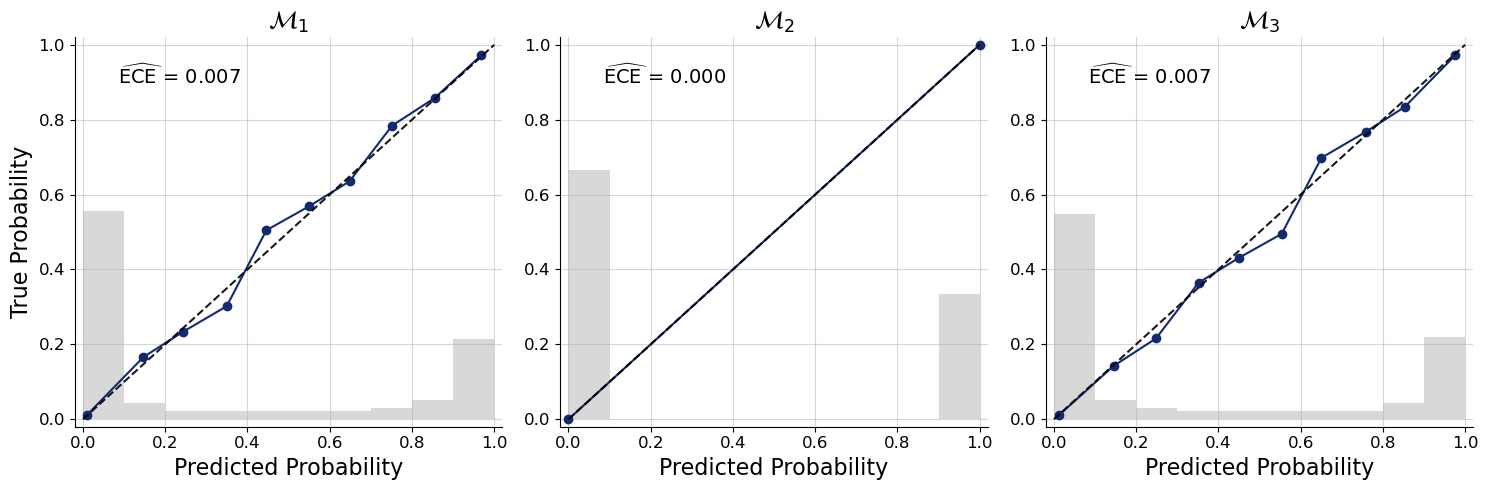

In [10]:
f = bf.diagnostics.plots.mc_calibration(
    pred_models=pred_models,
    true_models=df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$"],
)

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


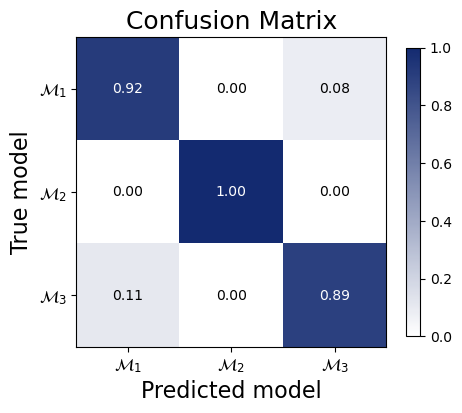

In [7]:
f = bf.diagnostics.plots.mc_confusion_matrix(
    pred_models=pred_models,
    true_models=df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$"],
    normalize="true",
)

In [11]:
# Save the trained approximator
filepath = Path("/Users/mandyking/benchmark/benchmark/examples/gaussian/networks") / "direct.keras"
filepath.parent.mkdir(exist_ok=True)
bayesflownpe.approximator.save(filepath=filepath)

In [12]:
# read datasets
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

datasets_normal_0  = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_normal_0.pkl")
datasets_normal_10 = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_normal_10.pkl")
datasets_student   = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_student_df10.pkl")

In [13]:
datasets_normal_0=bayesflownpe.get_probs(datasets_normal_0,approximator)
datasets_normal_10=bayesflownpe.get_probs(datasets_normal_10,approximator)
datasets_student=bayesflownpe.get_probs(datasets_student,approximator)

In [14]:
print(datasets_normal_0[0].keys())

dict_keys(['mu', 'obs_data', 'id', 'gold_log_marginal', 'gold_post_samples', 'npe_post_samples', 'npe_log_marginal', 'pred_model', 'logBF_12_direct', 'logBF_13_direct', 'logBF_23_direct'])


In [15]:
# save datasetst
def save_pickle(obj, path: str):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

save_pickle(datasets_normal_0,  "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/04datasets_normal_0.pkl")
save_pickle(datasets_normal_10, "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/04datasets_normal_10.pkl")
save_pickle(datasets_student,   "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/04datasets_student_df10.pkl")